<a href="https://colab.research.google.com/github/julmiha25-sys/MathStatistica/blob/main/%D0%A1%D1%82%D0%B0%D1%82%D0%B8%D1%81%D1%82%D0%B8%D0%BA%D0%B0_%D0%B7%D0%B0%D1%80%D0%BF%D0%BB%D0%B0%D1%82%D1%8B_%D0%B2_%D0%A0%D0%BE%D1%81%D1%81%D0%B8%D0%B8/%D0%9F%D1%80%D0%BE%D0%B5%D0%BA%D1%82_%D0%BF%D0%BE_%D0%BE%D0%BF%D0%B8%D1%81%D0%B0%D1%82%D0%B5%D0%BB%D1%8C%D0%BD%D0%BE%D0%B9_%D1%81%D1%82%D0%B0%D1%82%D0%B8%D1%81%D1%82%D0%B8%D0%BA%D0%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Размер первоначальной таблицы: (10000, 7)

Столбцы с пустыми значениями: ['Возраст', 'Уровень образования', 'Профессия', 'Регион'] 

Соотношение полов
женский: 50.32%
мужской: 49.68%

Соотношение городов
Москва: 28.70%
Санкт-Петербург: 18.79%
Нижний Новгород: 9.60%
Новосибирск: 9.58%
Екатеринбург: 9.51%
Казань: 9.46%
Челябинск: 9.41%
Омск: 4.96%

Соотношение степени образования
бакалавр: 33.10%
среднее общее: 23.26%
магистр: 21.55%
среднее профессиональное: 11.06%
доктор наук: 11.04%

Соотношение по возрасту
<25      16.99%
26-32    21.85%
33-39    21.87%
40-46    18.74%
47-53    10.95%
>54      7.52%

Соотношение по профессии
Девопс инженер: 5.77%
Инженер-программист: 5.73%
Строитель: 5.70%
Продуктовый менеджер: 5.65%
Актер: 5.61%
Бухгалтер: 5.39%
UX-дизайнер: 5.36%
Диджитал-маркетолог: 5.31%
Финансовый аналитик: 5.28%
Врач: 5.25%
Дизайнер интерфейсов: 5.23%
Инженер: 5.13%
Учитель: 5.07%
Водитель: 5.04%
Программист: 5.01%
Бизнес-аналитик: 4.91%
Маркетолог: 4.91%
Аналитик больших данны

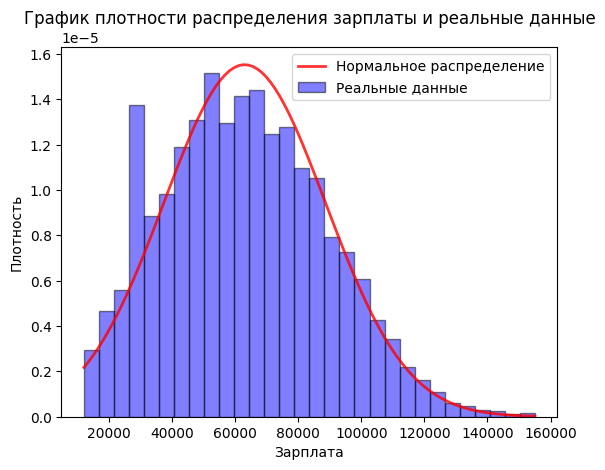

Описательные характеристики распределения заработной платы
Среднее:  62996.16
Несм. дисперсия:  660016386.32
Количество:  8122.00
Ассиметрия:  0.33
Эксцесс: -0.34
Мин:  12038.00
Макс:  155021.00
Мода: 31000.00
Стд отклонение: 25690.78
Размах: 142983.00
IQR: 37682.25
Медиана: 61778.00
Q1 (25%): 43301.00
Q3 (75%): 80983.25
Коэф. вариации: 40.8%

Город Москва
Среднее:  62624.77
Несм. дисперсия:  650197858.18
Количество:  2331.00
Ассиметрия:  0.31
Эксцесс: -0.40
Мин:  12317.00
Макс:  154777.00
Мода: 31000.00
Стд отклонение: 25498.98
Размах: 142460.00
IQR: 37182.00
Медиана: 61446.00
Q1 (25%): 43082.00
Q3 (75%): 80264.00
Коэф. вариации: 40.7%

Город Санкт-Петербург
Среднее:  63267.89
Несм. дисперсия:  644108684.67
Количество:  1526.00
Ассиметрия:  0.30
Эксцесс: -0.38
Мин:  12656.00
Макс:  151561.00
Мода: 31000.00
Стд отклонение: 25379.30
Размах: 138905.00
IQR: 37628.00
Медиана: 61451.50
Q1 (25%): 44010.75
Q3 (75%): 81638.75
Коэф. вариации: 40.1%

Город Нижний Новгород
Среднее:  62047.39
Несм

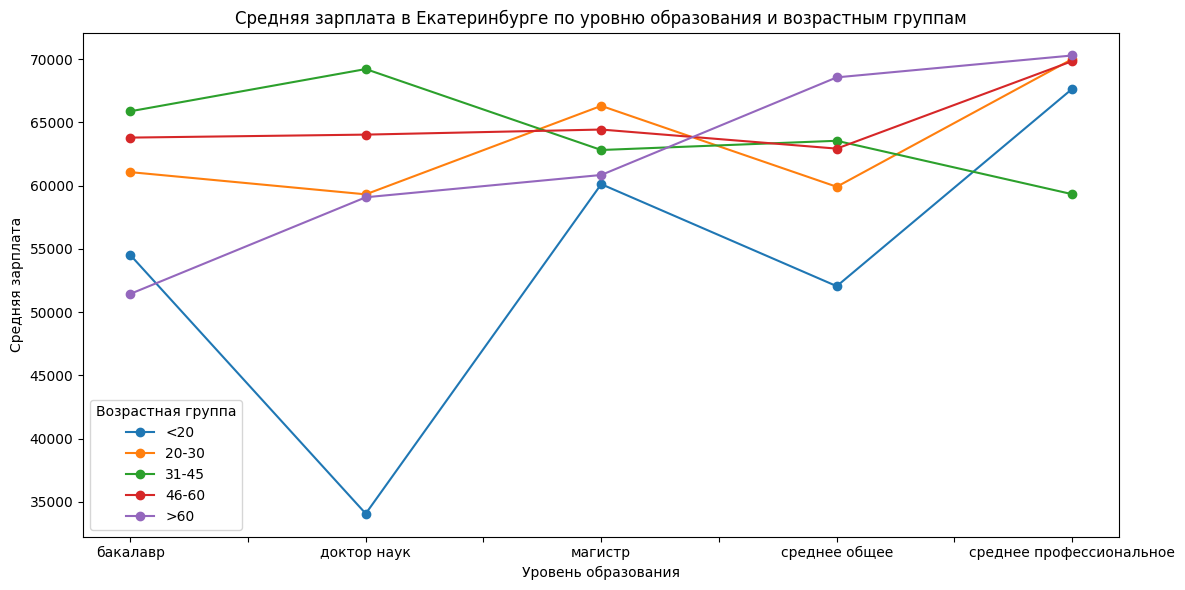

Максимальная средняя зарплата в Екатеринбурге составляет: 70279.00 при образовании: среднее профессиональное в возрастной группе: >60


In [79]:
import pandas as pd
from scipy.stats import norm
import scipy
import matplotlib.pyplot as plt
import numpy as np

df=pd.read_csv('Salary.csv', header=0)
# Первоначальная размерность таблицы
print(f"Размер первоначальной таблицы: {df.shape}\n")

# Поля с пропусками
empty_columns=df.columns[df.isnull().any()].tolist()
print("Столбцы с пустыми значениями:",empty_columns,"\n")

# Удаление пропусков
df1=df.dropna()
#print(df1.dtypes)
# Преобразование типа
df1.loc[:, 'Опыт работы']=df1['Опыт работы'].astype(int)
# Количество записей
total=len(df1)
# Группировка  по полу
pol_counts=df1['Пол'].value_counts()
# Группировка  по городам
city_counts=df1['Регион'].value_counts()
# Группировка по возрастам
groups=['<25','26-32','33-39','40-46','47-53','>54']
age=[df1['Возраст'].between(18, 25).sum(),df1['Возраст'].between(26, 32).sum(),
     df1['Возраст'].between(33, 39).sum(),df1['Возраст'].between(40, 46).sum(),
     df1['Возраст'].between(47, 53).sum(),df1['Возраст'].gt(54).sum()]
age_counts=pd.DataFrame({'Возраст':groups,'Количество': age})
# Группировка по степени образования
education_counts=df1['Уровень образования'].value_counts()
# Группировка по професмм
prof_counts=df1['Профессия'].value_counts()

# Вывод распределения данных по категориям
print("Соотношение полов")
for gender,count in pol_counts.items():
    percent=count/total*100
    print(f"{gender}: {percent:.2f}%")
print("\nСоотношение городов")
for city,count in city_counts.items():
    percent=count/total*100
    print(f"{city}: {percent:.2f}%")
print("\nСоотношение степени образования")
for education,count in education_counts.items():
    percent=count/total*100
    print(f"{education}: {percent:.2f}%")
print("\nСоотношение по возрасту")
for idx, row in age_counts.iterrows():
    percent = row['Количество']/total*100
    print(f"{row['Возраст']:8} {percent:.2f}%")
print("\nСоотношение по профессии")
for prof,count in prof_counts.items():
    percent=count/total*100
    print(f"{prof}: {percent:.2f}%")

zarp=df1['Зарплата']

def graph(df):
    # График плотности распределения зарплаты - нормальное распределение
    fig, ax = plt.subplots(1, 1)
    x=np.linspace(df.min(), df.max(), 100)
    d=norm.pdf(x,loc=df.mean(),scale=df.std())
    ax.plot(x, d, 'r-', lw=2, alpha=0.8, label='Нормальное распределение')
    ax.set_title('График плотности распределения зарплаты и реальные данные')
    ax.set_xlabel('Зарплата')
    ax.set_ylabel('Плотность')
    ax.hist(df, bins=30, density=True, alpha=0.5, color='blue', edgecolor='black', label='Реальные данные')
    ax.legend()
    plt.show()

def graph_line(df):
    # График распределения средней зарплаты в Екатеринбурге по уровню образования для возрастных промежутков
    df.unstack().plot(kind='line', marker='o', figsize=(12, 6))
    plt.title('Средняя зарплата в Екатеринбурге по уровню образования и возрастным группам')
    plt.ylabel('Средняя зарплата')
    plt.xlabel('Уровень образования')
    plt.legend(title='Возрастная группа')
    plt.tight_layout()
    plt.show()

def opis_stat(df):
    # Список всех параметров описательной ститистики
    q=scipy.stats.describe(df, axis=0, ddof=1, bias=True)
    print(f"Среднее: {q.mean: .2f}")
    print(f"Несм. дисперсия: {q.variance: .2f}")
    print(f"Количество: {q.nobs: .2f}")
    print(f"Ассиметрия: {q.skewness: .2f}")
    print(f"Эксцесс: {q.kurtosis: .2f}")
    print(f"Мин: {q.minmax[0]: .2f}")
    print(f"Макс: {q.minmax[1]: .2f}")
    print(f"Мода: {df.mode().values[0]:.2f}")
    print(f"Стд отклонение: {df.std():.2f}")
    print(f"Размах: {df.max()-df.min():.2f}")
    print(f"IQR: {df.quantile(0.75)-df.quantile(0.25):.2f}")
    print(f"Медиана: {df.median():.2f}")
    print(f"Q1 (25%): {df.quantile(0.25):.2f}")
    print(f"Q3 (75%): {df.quantile(0.75):.2f}")
    print(f"Коэф. вариации: {(df.std()/df.mean())*100:.1f}%")

graph(zarp)
# Описательные характеристики распределения зарплаты
print("Описательные характеристики распределения заработной платы")
opis_stat(zarp)

# Описательные характеристики распределения зарплаты по городам
for city in city_counts.index:
    print(f"\nГород {city}")
    zarp_city=df1[df1['Регион']==city]['Зарплата']
    opis_stat(zarp_city)

# Описательные характеристики распределения возраста
print("\nОписательные характеристики распределения возраста")
opis_stat(df1['Возраст'])

# Мода по категории Опыт работы
print(f"\nМода по категории Опыт работы: {df1['Опыт работы'].mode().values[0]}\n")

# Мода по категории Профессия для городов
for city in ['Москва','Санкт-Петербург','Омск','Казань']:
  print(f"Мода по категории Профессия для города {city}: {df1[df1['Регион']==city]['Профессия'].mode().values[0]}")

# Уровень образования с максимальной средней зарплатой по всем регионам
edu_zarp=df1.groupby('Уровень образования')['Зарплата'].mean()
print(f"\nМаксимальная средняя зарплата у уровня образования: {edu_zarp.idxmax()} со значением {edu_zarp.max():.2f}\n")

# Cредняя зарплата мужчин по профессиям
prof_zarp=df1[df1['Пол']=="мужской"].groupby('Профессия')['Зарплата'].mean().round(2)
for prof,zarp in prof_zarp.items():
    print(f"Для мужчин профессии {prof} средняя зарплата составляет: {zarp}")

# Регион с наименьшим медианным значением зарплаты для женщин
pol_zarp=df1[df1['Пол']=="женский"].groupby('Регион')['Зарплата'].median()
print(f"\nМинимальная медианная зарплата у женщин в регионе {pol_zarp.idxmin()} со значением {pol_zarp.min():.2f}\n")

# Средняя зарплата в Екатеринбурге по уровню образования для следующих возрастных промежутков:
# до 19, от 20 до 30, от 31 до 45, от 45 до 60, после 60
groups=[20,31,46,61,100]
# Границы интервалов для группировки
bins=[0]+groups
labels=['<20','20-30','31-45','46-60','>60']
df2=df1.copy()
# Разделение числовых данных на интервалы
df2['Возраст_группа']=pd.cut(df2['Возраст'],bins=bins,labels=labels)
edu_zarp=df2[df2['Регион']=="Екатеринбург"].groupby(['Уровень образования','Возраст_группа'],observed=False)['Зарплата'].mean()
graph_line(edu_zarp)
# Условия максимальной средней зарплаты в Екатеринбурге
for idx, val in edu_zarp[edu_zarp==edu_zarp.max()].items():
    print(f"Максимальная средняя зарплата в Екатеринбурге составляет: {edu_zarp.max():.2f} при образовании: {idx[0]} в возрастной группе: {idx[1]}")